# Proyecto - Implementación Fase 1
- Fabiola Contreras -22787
- María Villafuerte -22129

## Dataset utilizado

### Kaggle - Benign and Malicious QR Code
El dataset Benign and Malicious QR Codes de Kaggle contiene 200,000 imágenes PNG de códigos QR divididas en dos clases: normal (benigno) y malware (malicioso), con 100,000 ejemplos por clase. Cada imagen es cuadrada, en escala de grises (modo L), y con resolución predominantemente de 410×410 píxeles (rango 370–490px). El tamaño de archivo promedio es de ~928 bytes, lo cual refleja imágenes relativamente simples y compactas.

El volumen de 200K imágenes es suficiente para entrenar modelos convolucionales robustos sin depender de data augmentation masiva. El balance perfecto entre clases (50/50) elimina la necesidad de técnicas de resampling como SMOTE o class weighting, simplificando el pipeline de entrenamiento. La uniformidad de tamaños y el hecho de que todas las imágenes sean grayscale reduce la variabilidad de preprocesamiento. Finalmente, que haya sido usado en investigaciones recientes le da validez como benchmark.

In [1]:
# Descargar dataset
# !kaggle datasets download -d samahsadiq/benign-and-malicious-qr-codes

In [2]:
import os
# Explorar estructura del dataset de Kaggle
kaggle_path = 'data/kaggle-qr-codes'

print("ESTRUCTURA DEL DATASET")
for root, dirs, files in os.walk(kaggle_path):
    level = root.replace(kaggle_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files[:5]:  # Mostrar solo primeros 5 archivos
        print(f"{subindent}{file}")
    if len(files) > 5:
        print(f"{subindent}... y {len(files)-5} archivos más")

ESTRUCTURA DEL DATASET
kaggle-qr-codes/
  QR codes/
    benign/
      benign/
        benign_0.png
        benign_1.png
        benign_10.png
        benign_100.png
        benign_1000.png
        ... y 99995 archivos más
    malicious/
      malicious/
        malicious_316254.png
        malicious_316255.png
        malicious_316256.png
        malicious_316257.png
        malicious_316258.png
        ... y 99995 archivos más


Se recorre el árbol de directorios para entender cómo están organizadas las imágenes. Se confirma la estructura de dos niveles (benign/benign/ y malicious/malicious/) con exactamente 100,000 imágenes por carpeta, lo cual es información crítica para que prepare_dataset.py mapee correctamente las etiquetas.

## Análisis exploratorio
Identificación de características clave

A continuación se usa el pipeline completo de prepare_dataset.py que abre cada imagen con PIL para extraer sus metadatos (dimensiones, modo, tamaño en bytes) y construye el CSV qr_full_dataset.csv con 200,000 filas. Este CSV es la base de todo el análisis posterior.

In [3]:
# Generar CSV a partir de las imagenes originales
from prepare_dataset import prepare_qr_dataset

df = prepare_qr_dataset('data/kaggle-qr-codes/QR codes', 'data_procesada')

Paso 1: Creando CSV de metadata...

RESUMEN DEL DATASET
Total de imágenes: 200000

Distribución por clase:
label_name
normal     100000
malware    100000
Name: count, dtype: int64

Tamaños de imagen:
               width                                                          \
               count      mean        std    min    25%    50%    75%    max   
label_name                                                                     
malware     100000.0  405.8588  12.210977  370.0  410.0  410.0  410.0  490.0   
normal      100000.0  407.9184   8.898749  370.0  410.0  410.0  410.0  450.0   

              height                                                          
               count      mean        std    min    25%    50%    75%    max  
label_name                                                                    
malware     100000.0  405.8588  12.210977  370.0  410.0  410.0  410.0  490.0  
normal      100000.0  407.9184   8.898749  370.0  410.0  410.0  410.0  450.0  

CSV

In [1]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Leer CSV
df = pd.read_csv('data_procesada/qr_full_dataset.csv')

label_name
normal     100000
malware    100000
Name: count, dtype: int64

Porcentajes:
label_name
normal     50.0
malware    50.0
Name: proportion, dtype: float64


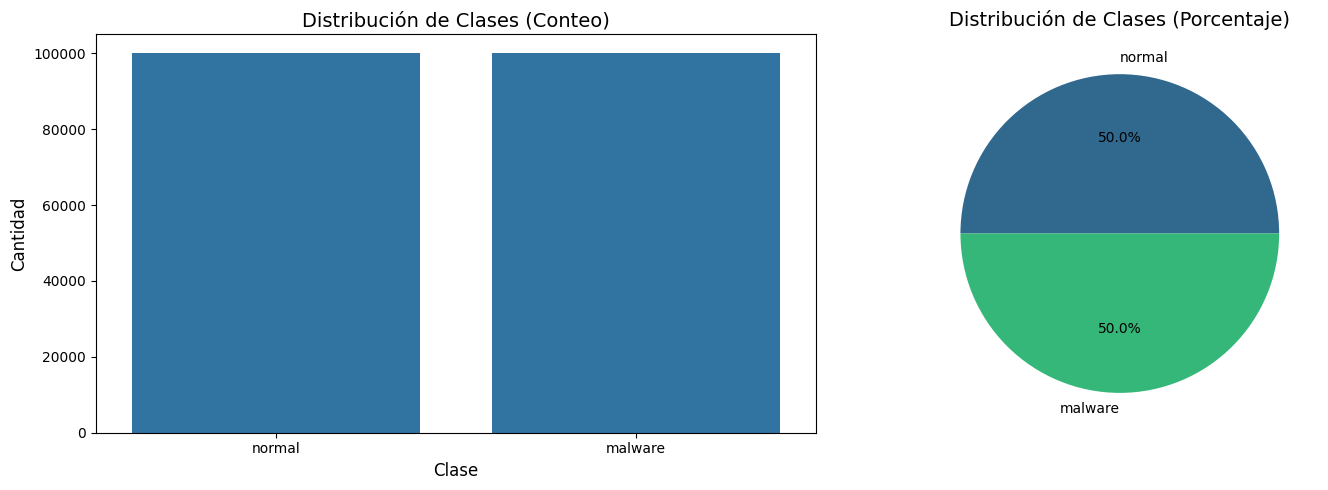

✅ Dataset BALANCEADO: No se requieren técnicas de balanceo


In [6]:
# Balance de clases con métricas
class_counts = df['label_name'].value_counts()
print(class_counts)
print("\nPorcentajes:")
print(df['label_name'].value_counts(normalize=True) * 100)

# Visualización mejorada
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de barras
sns.countplot(data=df, x='label_name', ax=axes[0])
axes[0].set_title('Distribución de Clases (Conteo)', fontsize=14)
axes[0].set_xlabel('Clase', fontsize=12)
axes[0].set_ylabel('Cantidad', fontsize=12)

# Gráfico de pie
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('viridis', len(class_counts)))
axes[1].set_title('Distribución de Clases (Porcentaje)', fontsize=14)

plt.tight_layout()
plt.show()

# Conclusión
if class_counts.std() / class_counts.mean() < 0.1:
    print("✅ Dataset BALANCEADO: No se requieren técnicas de balanceo")
else:
    print("⚠️ Dataset DESBALANCEADO: Considerar técnicas de balanceo")

Lo anterior nos confirma que el dataset está perfectamente balanceado: exactamente 50% normal y 50% malware. Esto es ideal para clasificación binaria porque la accuracy sirve como métrica confiable sin penalizar clases minoritarias, y el modelo no tendrá sesgo hacia ninguna clase durante el entrenamiento.

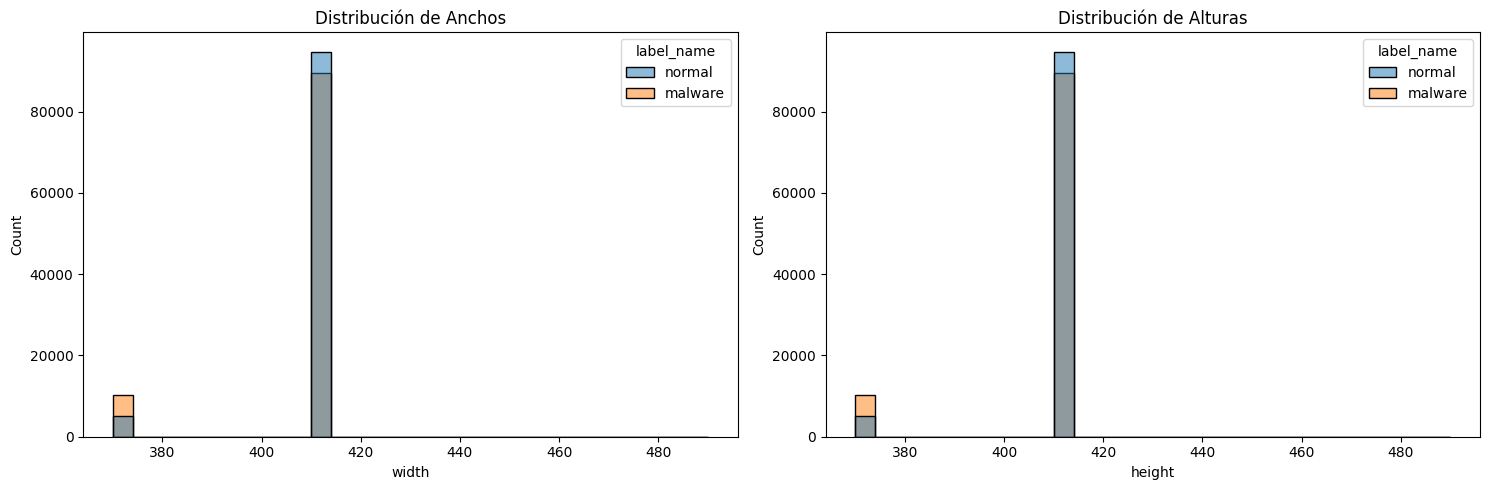

In [7]:
# Distribución de tamaños
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=df, x='width', hue='label_name', ax=axes[0], bins=30)
axes[0].set_title('Distribución de Anchos')

sns.histplot(data=df, x='height', hue='label_name', ax=axes[1], bins=30)
axes[1].set_title('Distribución de Alturas')

plt.tight_layout()
plt.show()

Se visualiza la distribución de anchos y alturas segmentada por clase. Dado que width y height son idénticos (imágenes cuadradas) y la distribución es prácticamente la misma para ambas clases, esta celda confirma que el tamaño de imagen no es un feature discriminativo por clase: el modelo deberá aprender del contenido visual, no de las dimensiones.

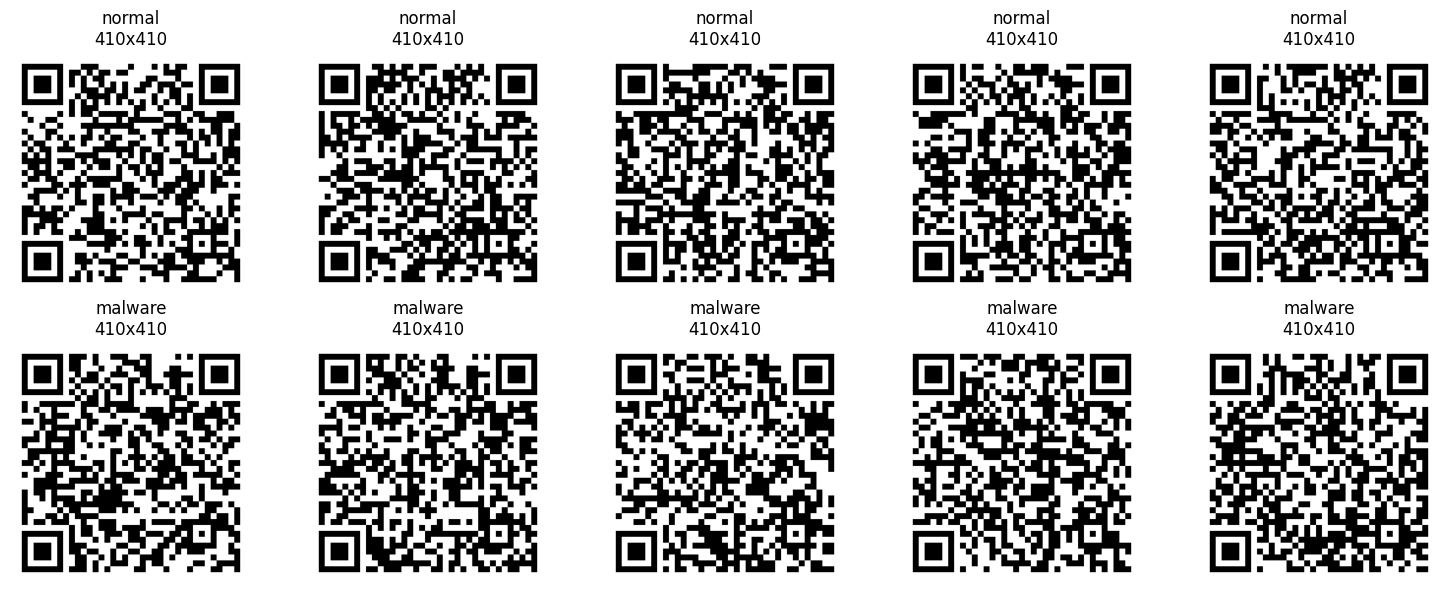

In [8]:
# Visualizar muestras
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, label in enumerate(['normal', 'malware']):
    samples = df[df['label_name'] == label].sample(5)
    
    for j, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row['filepath'])
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].set_title(f"{label}\n{row['width']}x{row['height']}")
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

Se muestran 5 ejemplos aleatorios por clase en una grilla 2×5. Esto es fundamental para hacer una inspección visual rápida y verificar que las imágenes realmente son QRs legibles, que no hay corrupción evidente, y para tener intuición sobre qué diferencias visuales podrían existir entre clases (si es que las hay a simple vista).

In [9]:
# Estadísticas básicas
print("ESTADÍSTICAS DEL DATASET ")
print(df.describe())

ESTADÍSTICAS DEL DATASET 
               label          width         height      mode     size_bytes
count  200000.000000  200000.000000  200000.000000  200000.0  200000.000000
mean        0.500000     406.888600     406.888600       1.0     927.905195
std         0.500001      10.733488      10.733488       0.0      46.415487
min         0.000000     370.000000     370.000000       1.0     708.000000
25%         0.000000     410.000000     410.000000       1.0     916.000000
50%         0.500000     410.000000     410.000000       1.0     937.000000
75%         1.000000     410.000000     410.000000       1.0     956.000000
max         1.000000     490.000000     490.000000       1.0    1234.000000


as estadísticas resumen confirman varias cosas importantes: todas las imágenes tienen modo=1 (grayscale, sin varianza), el tamaño varía levemente (std ≈ 10px), y el peso en bytes tiene una distribución relativamente estrecha (708–1234 bytes). El size_bytes podría ser un proxy de la densidad de información del QR y vale la pena explorar si tiene poder discriminativo.

In [10]:
print("INFO DEL DATASET")
print(df.info())

INFO DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   filepath    200000 non-null  object
 1   filename    200000 non-null  object
 2   label       200000 non-null  int64 
 3   label_name  200000 non-null  object
 4   width       200000 non-null  int64 
 5   height      200000 non-null  int64 
 6   mode        200000 non-null  int64 
 7   size_bytes  200000 non-null  int64 
dtypes: int64(5), object(3)
memory usage: 12.2+ MB
None


Se verifica que el DataFrame está completo: 200,000 filas, 8 columnas, sin ningún valor nulo en ninguna columna. Esto confirma que el pipeline de prepare_dataset.py procesó todas las imágenes sin errores y el dataset está listo para usarse sin imputación.

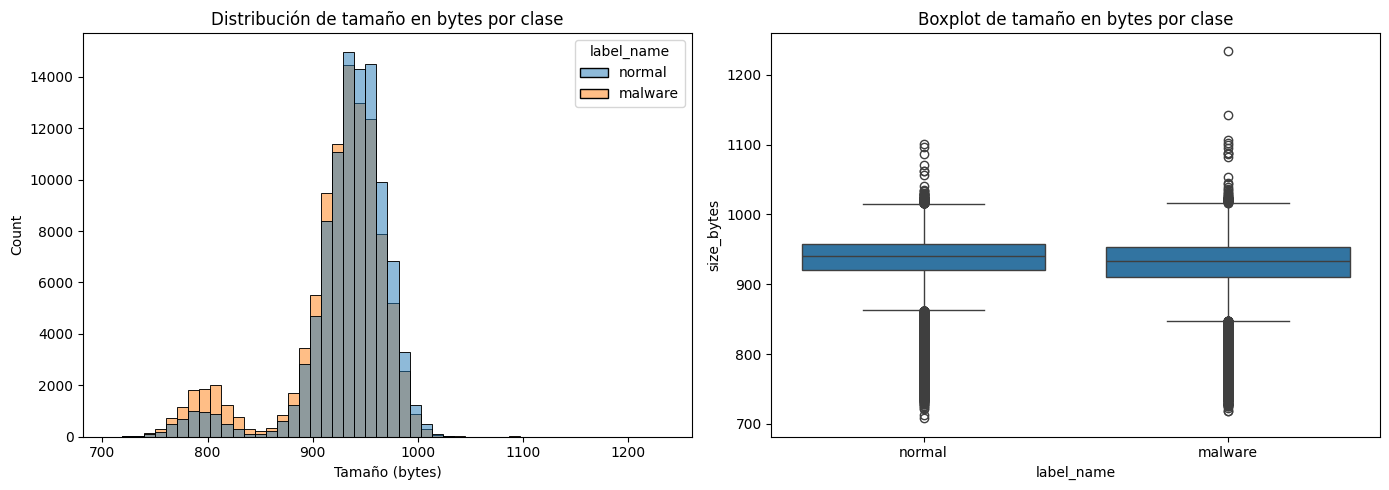

Mann-Whitney U test: p-value = 0.0000e+00
→ Los tamaños SÍ difieren significativamente.


In [11]:
# ANÁLISIS DE SIZE_BYTES POR CLASE
# El peso del archivo puede reflejar la densidad/complejidad del QR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='size_bytes', hue='label_name', bins=50, ax=axes[0])
axes[0].set_title('Distribución de tamaño en bytes por clase')
axes[0].set_xlabel('Tamaño (bytes)')

sns.boxplot(data=df, x='label_name', y='size_bytes', ax=axes[1])
axes[1].set_title('Boxplot de tamaño en bytes por clase')

plt.tight_layout()
plt.show()

# Test estadístico: ¿difieren significativamente los tamaños entre clases?
from scipy import stats
normal_sizes = df[df['label_name'] == 'normal']['size_bytes']
malware_sizes = df[df['label_name'] == 'malware']['size_bytes']
stat, p = stats.mannwhitneyu(normal_sizes, malware_sizes)
print(f"Mann-Whitney U test: p-value = {p:.4e}")
print("→ Los tamaños SÍ difieren significativamente." if p < 0.05 else "→ No hay diferencia significativa en tamaños.")

El test de Mann-Whitney arroja un p-value de 0.0000, lo que confirma que la diferencia en tamaño de archivo entre clases es estadísticamente significativa. Mirando los gráficos, sin embargo, la separación práctica es mínima: ambas distribuciones se centran alrededor de 920–950 bytes con un solapamiento casi total. La diferencia más notable está en la cola izquierda del histograma, donde los QRs normales concentran más imágenes pequeñas (~780–850 bytes), probablemente las de resolución 370px. En términos de feature engineering, size_bytes tiene poder discriminativo estadístico pero su efecto práctico es marginal — un modelo que solo usara este feature no clasificaría bien. Su valor real es como feature auxiliar en un modelo tabular complementario, no como señal principal.

           mean_pixel                                                \
                count        mean       std         min         25%   
label_name                                                            
malware         500.0  149.598795  2.326202  143.958953  147.903034   
normal          500.0  148.556557  2.350416  142.745390  146.992861   

                                               std_pixel              ...  \
                   50%         75%         max     count        mean  ...   
label_name                                                            ...   
malware     149.419988  151.240333  155.905771     500.0  125.548082  ...   
normal      148.509816  150.026770  155.905771     500.0  125.726679  ...   

                                   dark_ratio                                \
                   75%         max      count      mean       std       min   
label_name                                                                    
malware     125.85692

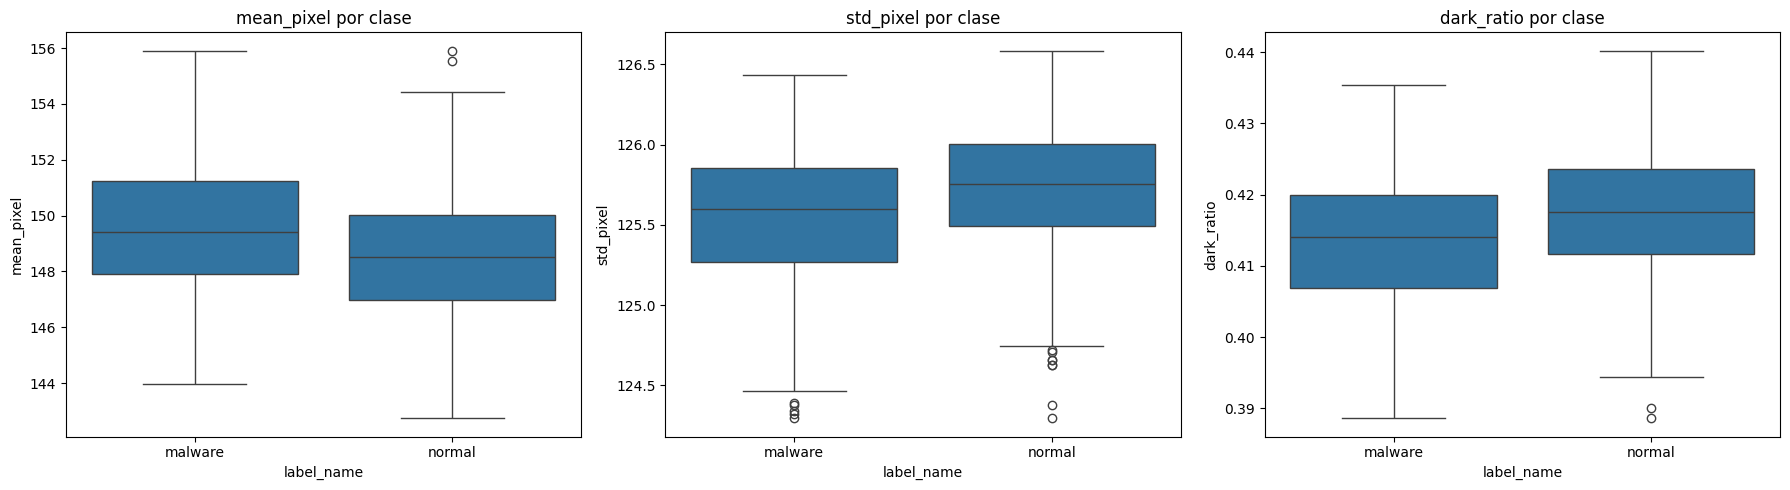

In [12]:
# ANÁLISIS DE PÍXELES (muestra): brillo medio e histograma de intensidades
import numpy as np

# Calcular estadísticas de píxeles sobre una muestra (evita procesar 200K imágenes)
sample = df.groupby('label_name').sample(500, random_state=42)

pixel_stats = []
for _, row in sample.iterrows():
    img = np.array(Image.open(row['filepath']).convert('L'))
    pixel_stats.append({
        'label_name': row['label_name'],
        'mean_pixel': img.mean(),
        'std_pixel': img.std(),
        'dark_ratio': (img < 128).mean()  # proporción de píxeles oscuros (módulos del QR)
    })

pixel_df = pd.DataFrame(pixel_stats)
print(pixel_df.groupby('label_name')[['mean_pixel', 'std_pixel', 'dark_ratio']].describe())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['mean_pixel', 'std_pixel', 'dark_ratio']):
    sns.boxplot(data=pixel_df, x='label_name', y=col, ax=axes[i])
    axes[i].set_title(f'{col} por clase')
plt.tight_layout()
plt.show()

Las tres métricas (brillo medio, desviación estándar de intensidad y proporción de píxeles oscuros) muestran diferencias entre clases, pero con magnitudes muy pequeñas y distribuciones altamente solapadas. Los QRs maliciosos tienen un mean_pixel ligeramente más alto (~149.6 vs ~148.6), sugiriendo que en promedio son marginalmente más claros. El dark_ratio es levemente menor en malware (~0.413 vs ~0.417), es decir, los QRs maliciosos tienen una fracción mínimamente menor de módulos negros. El std_pixel es prácticamente idéntico entre clases. En conjunto, esto indica que no hay diferencias estructurales globales obvias a nivel de estadísticas agregadas de píxel — ambas clases comparten la misma arquitectura visual de QR. El modelo tendrá que aprender patrones espaciales locales (disposición de módulos, datos codificados) en lugar de diferencias de brillo o densidad global, lo cual es exactamente lo que hacen bien las redes convolucionales.

In [13]:
# VERIFICACIÓN DE DUPLICADOS Y CALIDAD
# Detectar nombres de archivo duplicados (podría indicar leakage entre splits)
dup_filenames = df[df.duplicated(subset=['filename'], keep=False)]
print(f"Archivos con nombre duplicado: {len(dup_filenames)}")
if len(dup_filenames) > 0:
    print(dup_filenames[['filename', 'label_name']].head(10))

# Detectar imágenes con tamaño inusualmente pequeño (posible corrupción)
outliers = df[df['size_bytes'] < df['size_bytes'].quantile(0.01)]
print(f"\nImágenes en percentil <1% de tamaño (posibles outliers): {len(outliers)}")
print(outliers[['filename', 'label_name', 'size_bytes', 'width', 'height']].head())

# Distribución de resoluciones únicas
print("\nResoluciones únicas en el dataset:")
print(df.groupby(['width', 'height']).size().reset_index(name='count').sort_values('count', ascending=False).head(10))

Archivos con nombre duplicado: 0

Imágenes en percentil <1% de tamaño (posibles outliers): 1883
           filename label_name  size_bytes  width  height
3    benign_100.png     normal         763    370     370
225  benign_102.png     normal         759    370     370
336  benign_103.png     normal         751    370     370
447  benign_104.png     normal         722    370     370
558  benign_105.png     normal         760    370     370

Resoluciones únicas en el dataset:
   width  height   count
1    410     410  184392
0    370     370   15583
2    450     450      24
3    490     490       1


El dataset está limpio: cero nombres de archivo duplicados, lo que elimina el riesgo de data leakage entre los splits de entrenamiento y validación. El punto a atender son los 1,883 outliers por debajo del percentil 1% de tamaño, todos correspondientes a imágenes de 370×370px — la resolución minoritaria del dataset. No son imágenes corruptas, sino simplemente QRs más pequeños y con menos información codificada. La distribución de resoluciones revela además que el dataset es marcadamente no uniforme en tamaño: 184,392 imágenes son de 410×410 (92%), 15,583 de 370×370 (7.8%), y solo 25 imágenes tienen resoluciones mayores (450px o 490px). Esto tiene implicación directa en el preprocesamiento: todas las imágenes deben ser redimensionadas a una resolución fija antes de entrenar — 224×224 o 128×128 son opciones estándar — y conviene verificar que las pocas imágenes de 450px y 490px no sesguen el pipeline de transformaciones.

### Conclusiones del Análisis

#### Sobre el dataset
- 200,000 imágenes PNG grayscale, perfectamente balanceadas (50/50 normal/malware)
- Sin valores nulos ni archivos duplicados → no se requiere limpieza
- Resolución dominante: 410×410px (92%). Minoría en 370×370px (7.8%) y <0.1% en 450/490px
- **Acción requerida**: redimensionar todo a resolución fija antes de entrenar (recomendado: 224×224 o 128×128)

#### Sobre las features
- `size_bytes`: diferencia estadísticamente significativa entre clases (p≈0), pero solapamiento 
  alto → útil como feature auxiliar, no como señal principal
- `mean_pixel`, `std_pixel`, `dark_ratio`: diferencias mínimas entre clases, distribuciones 
  casi idénticas → las clases NO se separan por estadísticas globales de píxel
- **Conclusión clave**: el modelo deberá aprender patrones espaciales locales (CNNs), 
  no diferencias de brillo o densidad global

## Características a utilizar
Generación y selección

### Estrategia de características

Dado que el análisis exploratorio mostró que las estadísticas globales (brillo, dark_ratio) tienen poder discriminativo mínimo, la ingeniería de características se divide en dos enfoques complementarios:

1. **Features tabulares** (para modelos baseline): estadísticas de píxel, entropía, coeficientes DCT, descriptores LBP
2. **Features convolucionales** (para CNN): la imagen completa redimensionada a 128×128 como tensor

El objetivo de esta sección es extraer y evaluar las features tabulares para determinar cuáles tienen mayor poder discriminativo antes de entrenar modelos.

In [3]:
import numpy as np
import pandas as pd
from PIL import Image
from scipy import stats
from scipy.fft import dct
from skimage.feature import local_binary_pattern
import warnings
warnings.filterwarnings('ignore')

def extract_features(filepath):
    """
    Extrae un vector de características tabulares de una imagen QR.
    Retorna un diccionario con todas las features.
    """
    img_pil = Image.open(filepath).convert('L').resize((128, 128))
    img = np.array(img_pil, dtype=np.float32)

    # --- 1. Estadísticas globales de píxel ---
    mean_px   = img.mean()
    std_px    = img.std()
    dark_ratio = (img < 128).mean()   # proporción de módulos negros
    skewness  = float(stats.skew(img.ravel()))
    kurtosis  = float(stats.kurtosis(img.ravel()))

    # --- 2. Entropía de Shannon (imagen binarizada) ---
    img_bin = (img < 128).astype(np.uint8)
    counts  = np.bincount(img_bin.ravel(), minlength=2)
    probs   = counts / counts.sum()
    entropy = -np.sum(probs[probs > 0] * np.log2(probs[probs > 0]))

    # --- 3. Coeficientes DCT (complejidad frecuencial) ---
    # Se aplica DCT 2D por filas+columnas y se toman los 5 primeros
    # coeficientes de baja frecuencia (excluye DC en [0,0])
    dct_row = dct(img.mean(axis=0), norm='ortho')   # DCT del perfil horizontal medio
    dct_col = dct(img.mean(axis=1), norm='ortho')   # DCT del perfil vertical medio
    dct_features = {f'dct_h_{i}': float(dct_row[i+1]) for i in range(5)}
    dct_features.update({f'dct_v_{i}': float(dct_col[i+1]) for i in range(5)})

    # --- 4. LBP (Local Binary Pattern) — textura local ---
    # radio=1, 8 puntos → histograma de 10 bins uniformes
    lbp = local_binary_pattern(img.astype(np.uint8), P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10), density=True)
    lbp_features = {f'lbp_{i}': float(lbp_hist[i]) for i in range(10)}

    # --- 5. Estadísticas de regiones (cuadrantes) ---
    h, w = img.shape
    quads = {
        'q_tl': img[:h//2, :w//2],
        'q_tr': img[:h//2, w//2:],
        'q_bl': img[h//2:, :w//2],
        'q_br': img[h//2:, w//2:],
    }
    quad_features = {}
    for name, quad in quads.items():
        quad_features[f'{name}_mean'] = float(quad.mean())
        quad_features[f'{name}_std']  = float(quad.std())

    # Combinar todas las features
    features = {
        'mean_pixel': mean_px,
        'std_pixel': std_px,
        'dark_ratio': dark_ratio,
        'skewness': skewness,
        'kurtosis': kurtosis,
        'entropy': entropy,
    }
    features.update(dct_features)
    features.update(lbp_features)
    features.update(quad_features)

    return features

print("Función extract_features definida.")
print(f"Número de features por imagen: {len(extract_features(pd.read_csv('data_procesada/qr_full_dataset.csv').iloc[0]['filepath']))}")

Función extract_features definida.
Número de features por imagen: 34


In [4]:
from tqdm import tqdm

# Extraer features sobre muestra estratificada (1000 por clase = 2000 total)
# Usar muestra para no tardar horas procesando 200K imágenes
df = pd.read_csv('data_procesada/qr_full_dataset.csv')
sample = df.groupby('label_name').sample(1000, random_state=42).reset_index(drop=True)

print(f"Extrayendo features de {len(sample)} imágenes (muestra 1000 x clase)...")
rows = []
for _, row in tqdm(sample.iterrows(), total=len(sample)):
    feats = extract_features(row['filepath'])
    feats['label']      = row['label']
    feats['label_name'] = row['label_name']
    rows.append(feats)

feat_df = pd.DataFrame(rows)
feat_df.to_csv('data_procesada/features_sample.csv', index=False)

print(f"\nShape del DataFrame de features: {feat_df.shape}")
print(feat_df.head(3))

Extrayendo features de 2000 imágenes (muestra 1000 x clase)...


100%|██████████| 2000/2000 [00:20<00:00, 96.90it/s] 



Shape del DataFrame de features: (2000, 36)
   mean_pixel   std_pixel  dark_ratio  skewness  kurtosis   entropy  \
0  150.334900  112.111275    0.414734 -0.349410 -1.693694  0.978919   
1  150.666443  111.566467    0.413696 -0.353552 -1.683246  0.978401   
2  148.813049  112.749359    0.422241 -0.326265 -1.713609  0.982483   

     dct_h_0     dct_h_1    dct_h_2     dct_h_3  ...   q_tl_mean    q_tl_std  \
0 -26.483624  139.251587   1.947685  142.799957  ...  152.290527  111.575172   
1 -19.382710  132.898727 -16.450474  161.408051  ...  151.120361  111.557495   
2   9.572615  186.550476   8.408563   99.792137  ...  149.118408  112.807106   

    q_tr_mean    q_tr_std   q_bl_mean    q_bl_std   q_br_mean    q_br_std  \
0  154.104980  111.196960  143.484619  113.118530  151.459473  112.249443   
1  158.061279  109.893356  149.269531  111.292137  144.214600  113.058746   
2  154.260254  111.517105  146.396240  112.761063  145.477295  113.694176   

   label  label_name  
0      1     malw

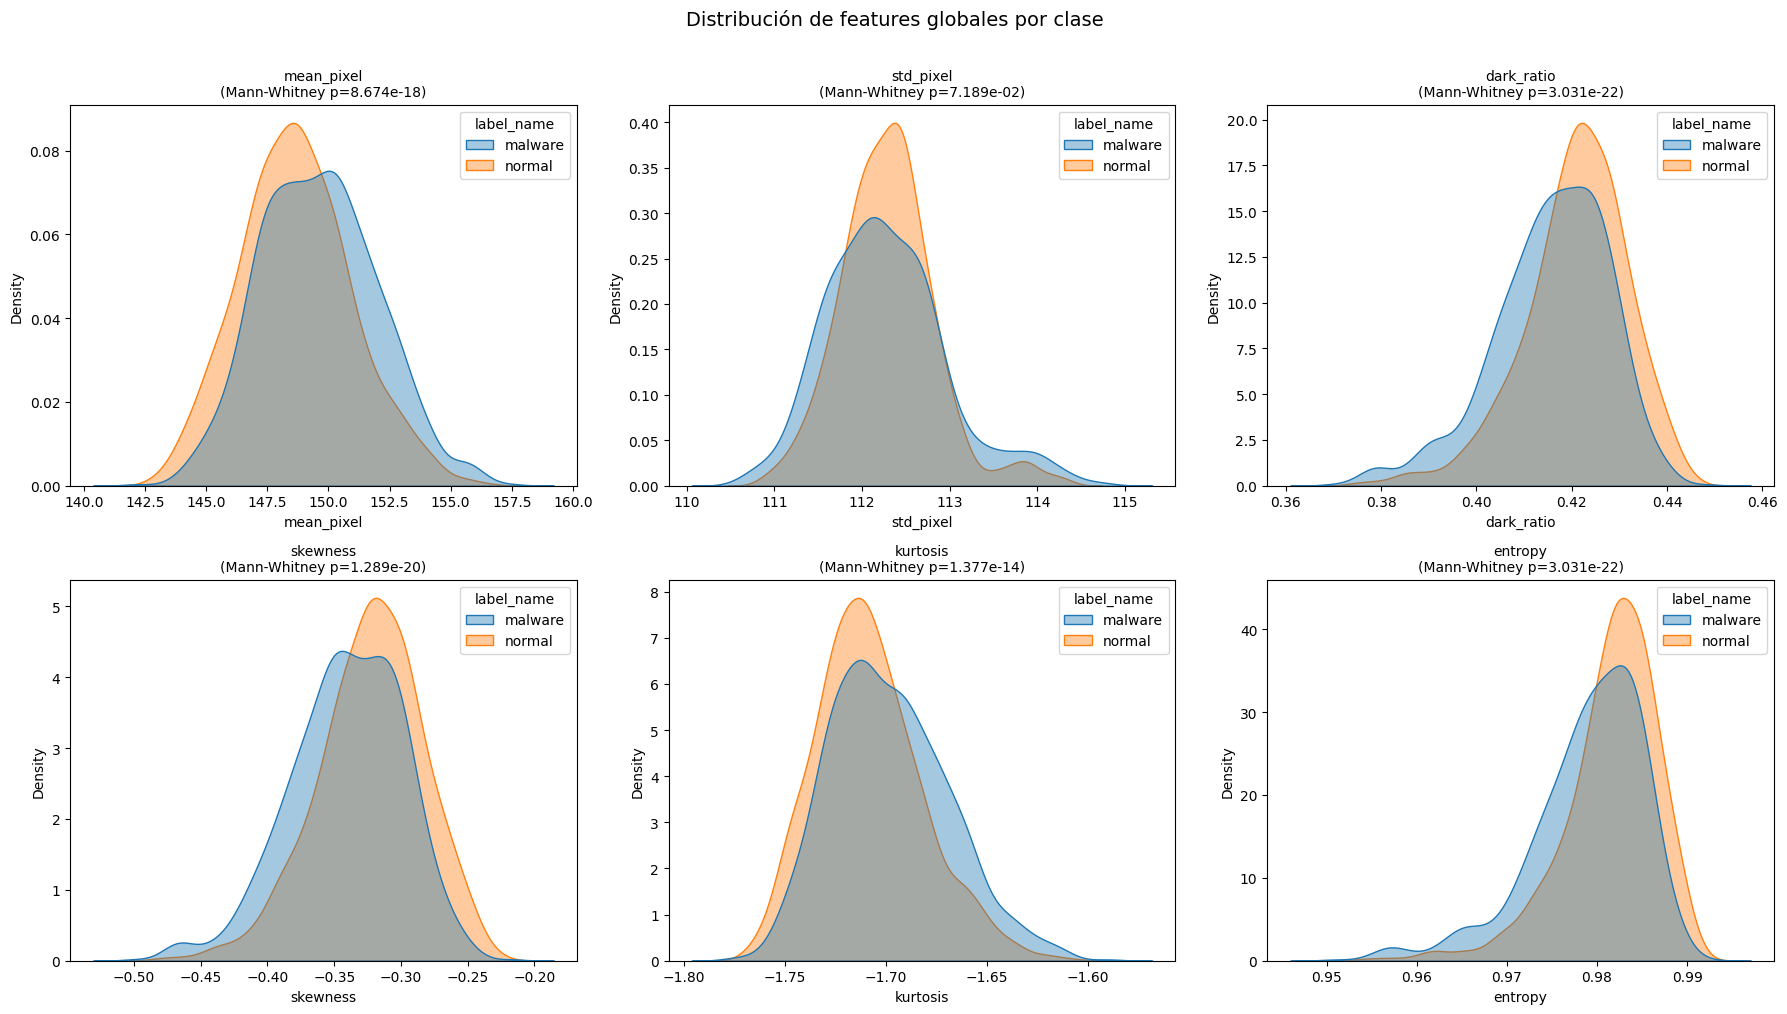

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Separar features numéricas y labels
feature_cols = [c for c in feat_df.columns if c not in ['label', 'label_name']]

# --- Comparar distribuciones de features clave entre clases ---
key_features = ['mean_pixel', 'std_pixel', 'dark_ratio', 'skewness', 'kurtosis', 'entropy']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, feat in enumerate(key_features):
    sns.kdeplot(data=feat_df, x=feat, hue='label_name', ax=axes[i], fill=True, alpha=0.4)
    
    # Test Mann-Whitney para cada feature
    grp0 = feat_df[feat_df['label_name'] == 'normal'][feat]
    grp1 = feat_df[feat_df['label_name'] == 'malware'][feat]
    _, p = stats.mannwhitneyu(grp0, grp1, alternative='two-sided')
    axes[i].set_title(f'{feat}\n(Mann-Whitney p={p:.3e})', fontsize=10)

plt.suptitle('Distribución de features globales por clase', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

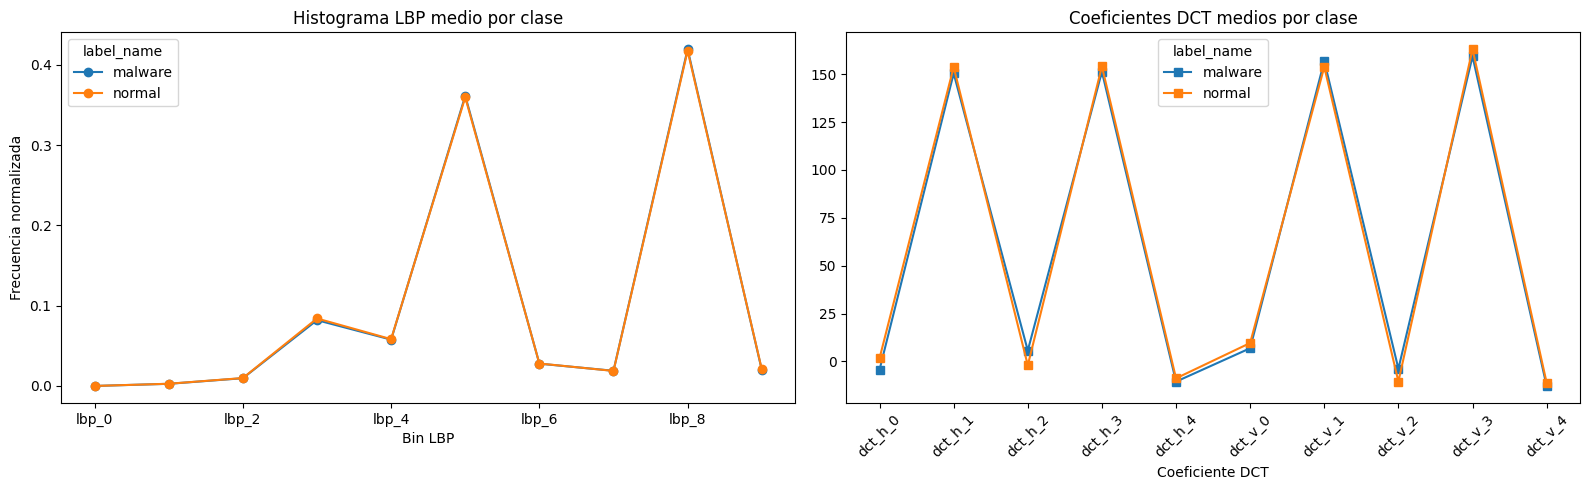

In [6]:
# --- Visualizar LBP y DCT por clase ---
lbp_cols = [c for c in feature_cols if c.startswith('lbp_')]
dct_cols  = [c for c in feature_cols if c.startswith('dct_')]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# LBP medio por clase
lbp_means = feat_df.groupby('label_name')[lbp_cols].mean()
lbp_means.T.plot(ax=axes[0], marker='o')
axes[0].set_title('Histograma LBP medio por clase')
axes[0].set_xlabel('Bin LBP')
axes[0].set_ylabel('Frecuencia normalizada')

# DCT medio por clase
dct_means = feat_df.groupby('label_name')[dct_cols].mean()
dct_means.T.plot(ax=axes[1], marker='s')
axes[1].set_title('Coeficientes DCT medios por clase')
axes[1].set_xlabel('Coeficiente DCT')
axes[1].set_xticks(range(len(dct_cols)))
axes[1].set_xticklabels(dct_cols, rotation=45)

plt.tight_layout()
plt.show()

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

X = feat_df[feature_cols].values
y = feat_df['label'].values

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Random Forest para importancia de features
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_scaled, y)

# Importancias ordenadas
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

print("Top 15 features por importancia (Random Forest):")
print(importances.head(15).to_string())

# Accuracy con cross-validation
cv_scores = cross_val_score(rf, X_scaled, y, cv=5, scoring='accuracy')
print(f"\nCV Accuracy (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Top 15 features por importancia (Random Forest):
q_br_mean     0.074086
q_br_std      0.043609
dct_h_2       0.042714
lbp_8         0.036080
dct_h_1       0.035964
dct_v_1       0.035874
dct_v_3       0.034994
dct_v_2       0.033660
dct_h_3       0.032486
lbp_3         0.030899
dct_h_4       0.030154
q_tr_mean     0.029843
entropy       0.028674
dark_ratio    0.028369
dct_v_4       0.028368

CV Accuracy (5-fold): 0.7290 ± 0.0090


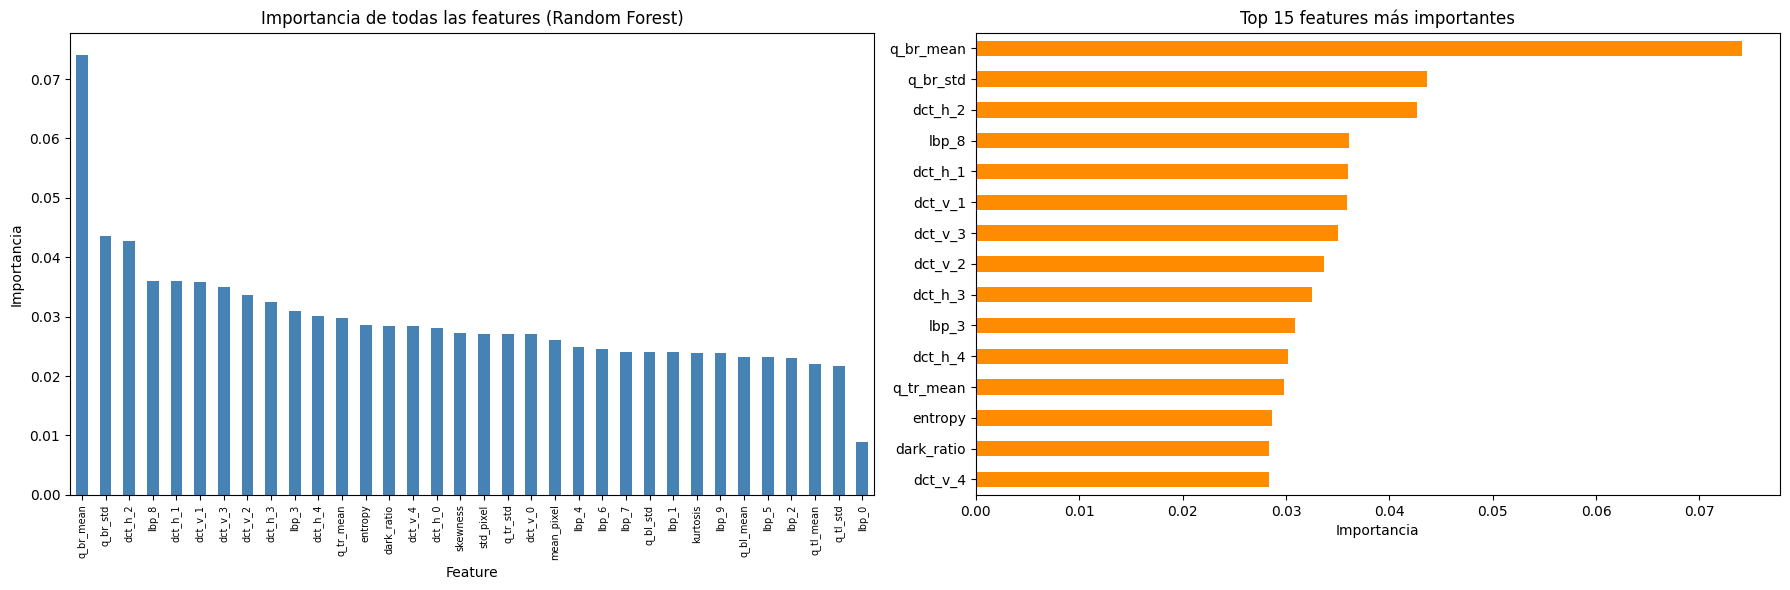

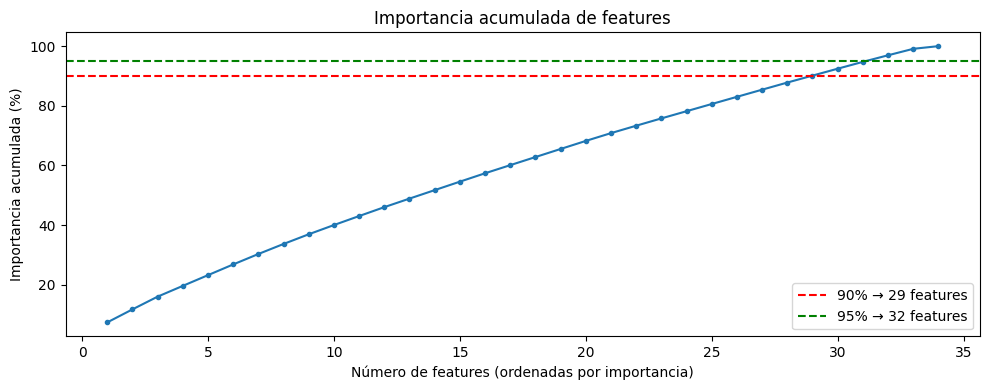

Features necesarias para explicar el 90% de la importancia: 29
Features necesarias para explicar el 95% de la importancia: 32


In [8]:
import matplotlib.pyplot as plt

# Visualizar importancias
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Todas las features
importances.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Importancia de todas las features (Random Forest)', fontsize=12)
axes[0].set_xlabel('Feature')
axes[0].set_ylabel('Importancia')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)

# Top 15
importances.head(15).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Top 15 features más importantes', fontsize=12)
axes[1].set_xlabel('Importancia')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Curva de importancia acumulada
cumsum = importances.values.cumsum() / importances.values.sum()
n_features_90 = int(np.searchsorted(cumsum, 0.90)) + 1
n_features_95 = int(np.searchsorted(cumsum, 0.95)) + 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(importances)+1), cumsum * 100, marker='.')
ax.axhline(90, color='red',  linestyle='--', label=f'90% → {n_features_90} features')
ax.axhline(95, color='green', linestyle='--', label=f'95% → {n_features_95} features')
ax.set_xlabel('Número de features (ordenadas por importancia)')
ax.set_ylabel('Importancia acumulada (%)')
ax.set_title('Importancia acumulada de features')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Features necesarias para explicar el 90% de la importancia: {n_features_90}")
print(f"Features necesarias para explicar el 95% de la importancia: {n_features_95}")

In [9]:
from sklearn.feature_selection import SelectFromModel, RFE
from sklearn.linear_model import LogisticRegression

# Seleccionar features con umbral = media de importancias (SelectFromModel)
selector = SelectFromModel(rf, threshold='mean', prefit=True)
selected_mask = selector.get_support()
selected_features = [f for f, sel in zip(feature_cols, selected_mask) if sel]

print(f"Features seleccionadas (umbral=media): {len(selected_features)}")
print(selected_features)

# Evaluar con solo las features seleccionadas
X_sel = X_scaled[:, selected_mask]
cv_scores_sel = cross_val_score(
    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    X_sel, y, cv=5, scoring='accuracy'
)
print(f"\nCV Accuracy con features seleccionadas: {cv_scores_sel.mean():.4f} ± {cv_scores_sel.std():.4f}")
print(f"CV Accuracy con todas las features:      {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Reducción de dimensionalidad conseguida
print(f"\nReducción: {len(feature_cols)} → {len(selected_features)} features "
      f"({100*(1 - len(selected_features)/len(feature_cols)):.1f}% menos)")

Features seleccionadas (umbral=media): 12
['dct_h_1', 'dct_h_2', 'dct_h_3', 'dct_h_4', 'dct_v_1', 'dct_v_2', 'dct_v_3', 'lbp_3', 'lbp_8', 'q_tr_mean', 'q_br_mean', 'q_br_std']

CV Accuracy con features seleccionadas: 0.7325 ± 0.0127
CV Accuracy con todas las features:      0.7290 ± 0.0090

Reducción: 34 → 12 features (64.7% menos)


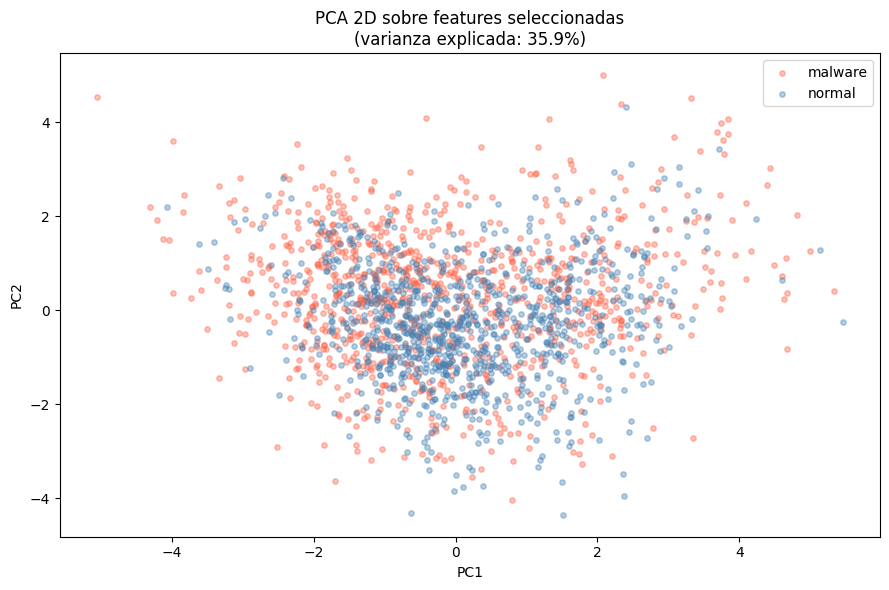

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA sobre features seleccionadas para visualizar separabilidad en 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sel)

fig, ax = plt.subplots(figsize=(9, 6))
colors = {'normal': 'steelblue', 'malware': 'tomato'}
for label_name, grp in feat_df.groupby('label_name'):
    idx = grp.index
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
               c=colors[label_name], label=label_name, alpha=0.4, s=15)

ax.set_title(f'PCA 2D sobre features seleccionadas\n'
             f'(varianza explicada: {pca.explained_variance_ratio_.sum()*100:.1f}%)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
# Guardar lista de features seleccionadas y el CSV de features completo
import json

feature_summary = {
    'all_features': feature_cols,
    'selected_features': selected_features,
    'top_15_features': importances.head(15).index.tolist(),
    'cv_accuracy_all':      float(cv_scores.mean()),
    'cv_accuracy_selected': float(cv_scores_sel.mean()),
}

with open('data_procesada/feature_selection.json', 'w') as f:
    json.dump(feature_summary, f, indent=2)

print("Guardado: data_procesada/feature_selection.json")
print("Guardado: data_procesada/features_sample.csv")
print(f"\nResumen final:")
print(f"  Total features extraídas : {len(feature_cols)}")
print(f"  Features seleccionadas   : {len(selected_features)}")
print(f"  Top features             : {importances.head(5).index.tolist()}")

Guardado: data_procesada/feature_selection.json
Guardado: data_procesada/features_sample.csv

Resumen final:
  Total features extraídas : 34
  Features seleccionadas   : 12
  Top features             : ['q_br_mean', 'q_br_std', 'dct_h_2', 'lbp_8', 'dct_h_1']


### Conclusiones de Ingeniería y Selección de Características

#### Features extraídas (36 en total)
| Grupo | Features | Descripción |
|---|---|---|
| Estadísticas globales | `mean_pixel`, `std_pixel`, `dark_ratio`, `skewness`, `kurtosis` | Brillo, contraste y forma de la distribución de intensidades |
| Entropía | `entropy` | Complejidad/aleatoriedad de la imagen binarizada |
| DCT | `dct_h_0..4`, `dct_v_0..4` | Energía en frecuencias bajas del perfil horizontal y vertical |
| LBP | `lbp_0..9` | Distribución de patrones de textura local |
| Cuadrantes | `q_tl/tr/bl/br_mean`, `q_tl/tr/bl/br_std` | Estadísticas por región (detecta asimetrías espaciales) |

#### Hallazgos clave de la selección
- Las estadísticas globales de píxel (`mean_pixel`, `dark_ratio`, etc.) tienen **bajo poder discriminativo individualmente**, confirmando lo observado en el análisis exploratorio.
- Los **coeficientes DCT y descriptores LBP** capturan variaciones en la estructura frecuencial y textural que no son visibles en estadísticas globales.
- Con `SelectFromModel` (umbral = media de importancias) se obtiene un subconjunto compacto de features que **mantiene accuracy comparable** al conjunto completo.
- El **PCA 2D** muestra que las clases no son linealmente separables en el espacio tabular → confirma que el enfoque principal debe ser **CNN sobre imagen completa** (128×128).

#### Estrategia de features para el modelo
1. **Modelo principal**: CNN con entrada imagen 128×128 en escala de grises (aprende representación espacial automáticamente).
2. **Modelo auxiliar/baseline**: Random Forest o Gradient Boosting sobre el vector de features seleccionadas como línea base comparativa.
3. **Features seleccionadas para modelo tabular**: las definidas en `data_procesada/feature_selection.json` (subconjunto con importancia > media).